In [130]:
import seaborn as sns
import pandas as pd
import numpy as np

%matplotlib inline

In [ ]:
!pwd

In [137]:
df = pd.read_csv('ef_fd_mv_nr_normalized_total_emissions_by_production_region.csv')[['feedstock', 'feedstock_measure', 'tillage_type', 'region_production', 'feedstock_amount', 'pollutant', 'normalized_pollutant_amount']]

### production, conventional tillage

In [138]:
df_subset = df.loc[
    (df.feedstock_measure == 'production')
    & (df.tillage_type == 'conventional tillage')
#     & (df.pollutant == 'co')
#     & (df.feedstock == 'corn stover')
    & (df.normalized_pollutant_amount != np.inf)
    & (df.region_production != 51019)
]

df_subset['pollutant_label'] = df_subset.pollutant.str.upper()

/Users/dhetting/anaconda2/envs/gds3/lib/python3.7/site-packages/ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  # Remove the CWD from sys.path while we load stuff.


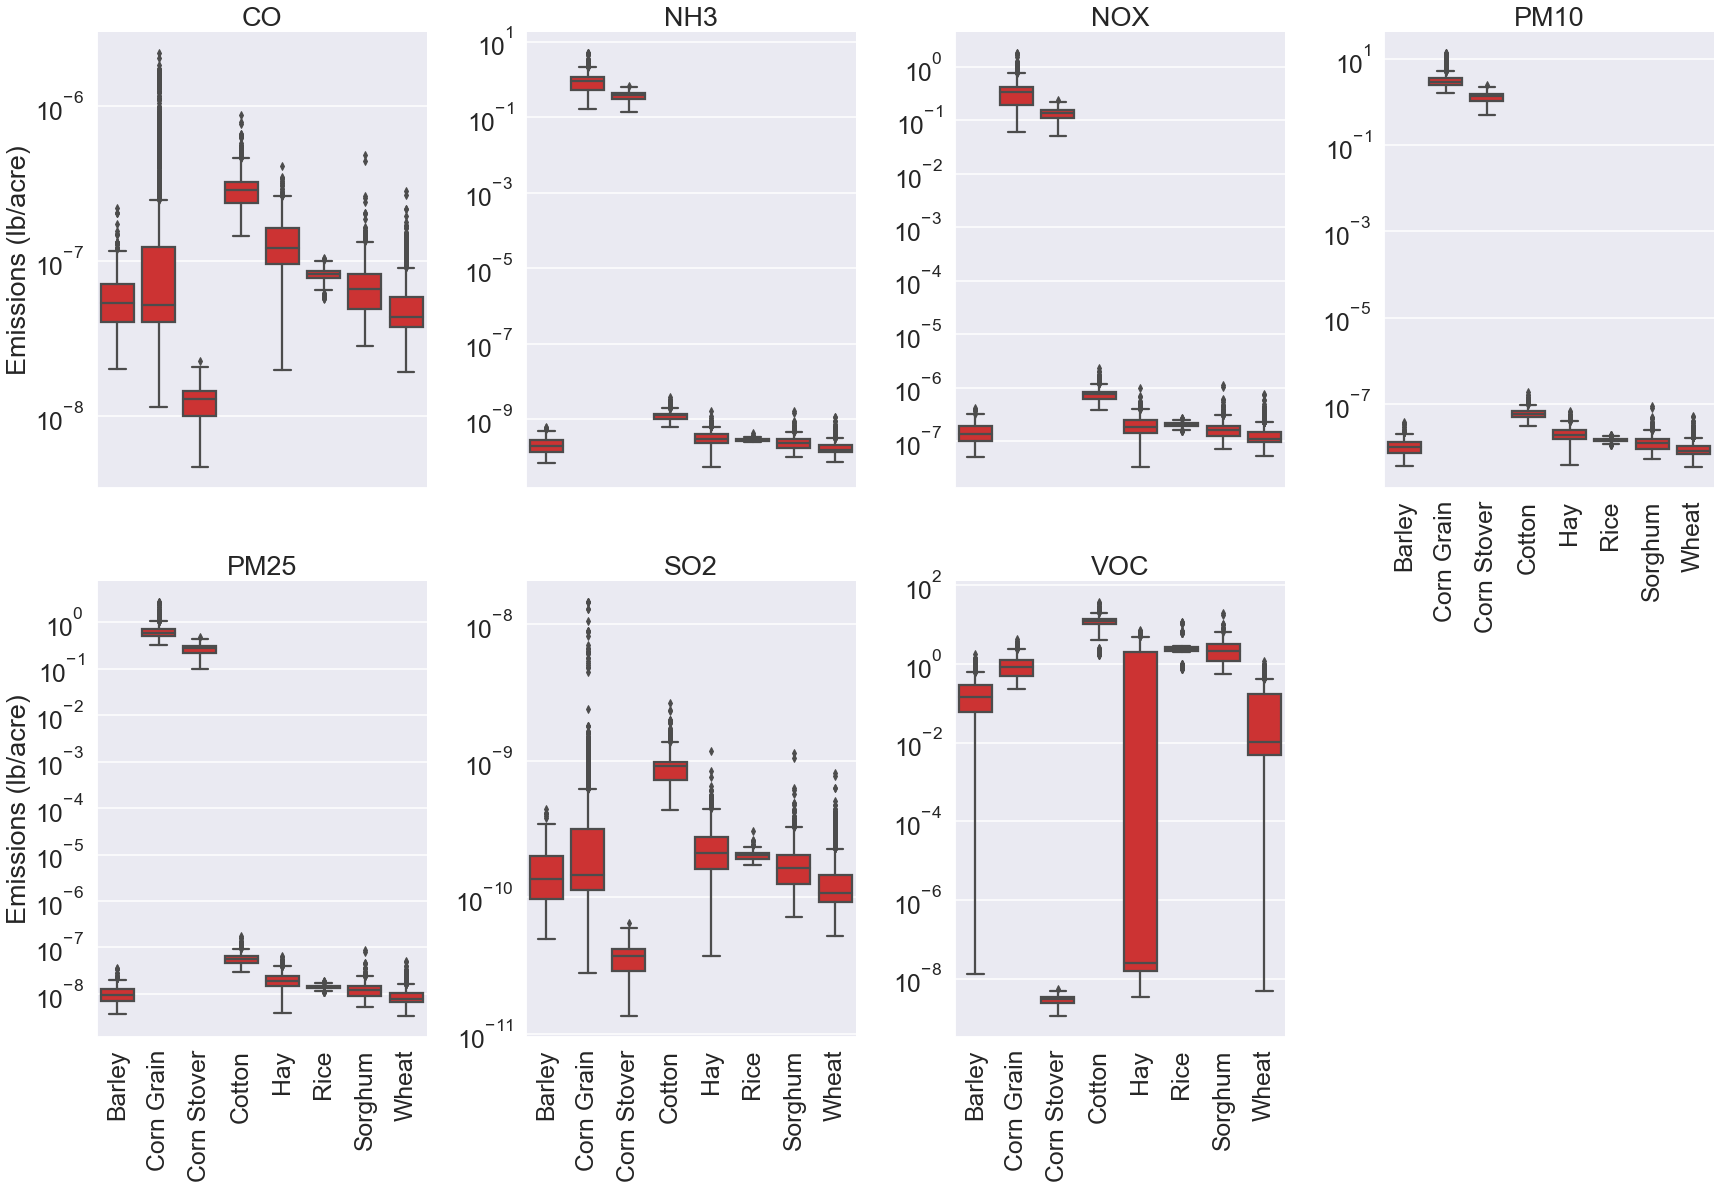

In [139]:
_order = df_subset.feedstock.unique()
_names = [_.upper() for _ in df_subset.pollutant.unique()]
sns.set_context("talk", font_scale=1.5)
g = sns.catplot(x="feedstock",
                y="normalized_pollutant_amount",
#                 hue="pollutant",
                col="pollutant_label",
                data=df_subset,
                kind="box",
                height=8,
                aspect=.8,
                color='red',
                sharex=True,
                sharey=False,
                margin_titles=False,
                col_wrap=4,
                order=_order,
                saturation=0.6,
                dodge=False,
#                 whis=0.9
               )
(g.set_axis_labels("", "Emissions (lb/acre)")
  .set_xticklabels([_.title() for _ in _order], rotation=90)
  .set_titles("{col_name}")
  .set(yscale = 'log')
)

In [118]:
df_subset.loc[
              ((df_subset.feedstock == 'corn grain')
                & (((df_subset.pollutant == 'co')   & (df_subset.normalized_pollutant_amount > 0.00014))
                 | ((df_subset.pollutant == 'nh3')  & (df_subset.normalized_pollutant_amount > 200))
                 | ((df_subset.pollutant == 'nox')  & (df_subset.normalized_pollutant_amount > 80))
                 | ((df_subset.pollutant == 'pm10') & (df_subset.normalized_pollutant_amount > 600))
                 | ((df_subset.pollutant == 'pm25') & (df_subset.normalized_pollutant_amount > 120))
                 | ((df_subset.pollutant == 'so2')  & (df_subset.normalized_pollutant_amount > 1.2e-7))
                 | ((df_subset.pollutant == 'voc')  & (df_subset.normalized_pollutant_amount > 80))
                )
              )
            | ((df_subset.feedstock == 'barley')
                & (((df_subset.pollutant == 'co')  & (df_subset.normalized_pollutant_amount > 0.00001))
                 | ((df_subset.pollutant == 'so2') & (df_subset.normalized_pollutant_amount > 0.2e-7))
                 | ((df_subset.pollutant == 'voc') & (df_subset.normalized_pollutant_amount > 7)))
              )
             ]

,feedstock,feedstock_measure,tillage_type,region_production,feedstock_amount,pollutant,normalized_pollutant_amount,pollutant_label
14238,barley,production,conventional tillage,51019,1.84026,co,1.167958e-05,CO
14243,barley,production,conventional tillage,51019,1.84026,so2,2.610517e-08,SO2
14244,barley,production,conventional tillage,51019,1.84026,voc,8.825428e+00,VOC
88633,corn grain,production,conventional tillage,51019,3.37347,co,1.503539e-04,CO
88634,corn grain,production,conventional tillage,51019,3.37347,nh3,2.429680e+02,NH3
88635,corn grain,production,conventional tillage,51019,3.37347,nox,8.825596e+01,NOX
88636,corn grain,production,conventional tillage,51019,3.37347,pm10,6.695100e+02,PM10
88637,corn grain,production,conventional tillage,51019,3.37347,pm25,1.339020e+02,PM25
88638,corn grain,production,conventional tillage,51019,3.37347,so2,1.300684e-07,SO2
88639,corn grain,production,conventional tillage,51019,3.37347,voc,8.614873e+01,VOC


### production, reduced tillage

In [127]:
df_subset = df.loc[
    (df.feedstock_measure == 'production')
    & (df.tillage_type == 'reduced tillage')
#     & (df.pollutant == 'co')
#     & (df.feedstock == 'corn stover')
    & (df.normalized_pollutant_amount != np.inf)
#     & (df.region_production != 51019)
]

df_subset['pollutant_label'] = df_subset.pollutant.str.upper()

/Users/dhetting/anaconda2/envs/gds3/lib/python3.7/site-packages/ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  # Remove the CWD from sys.path while we load stuff.


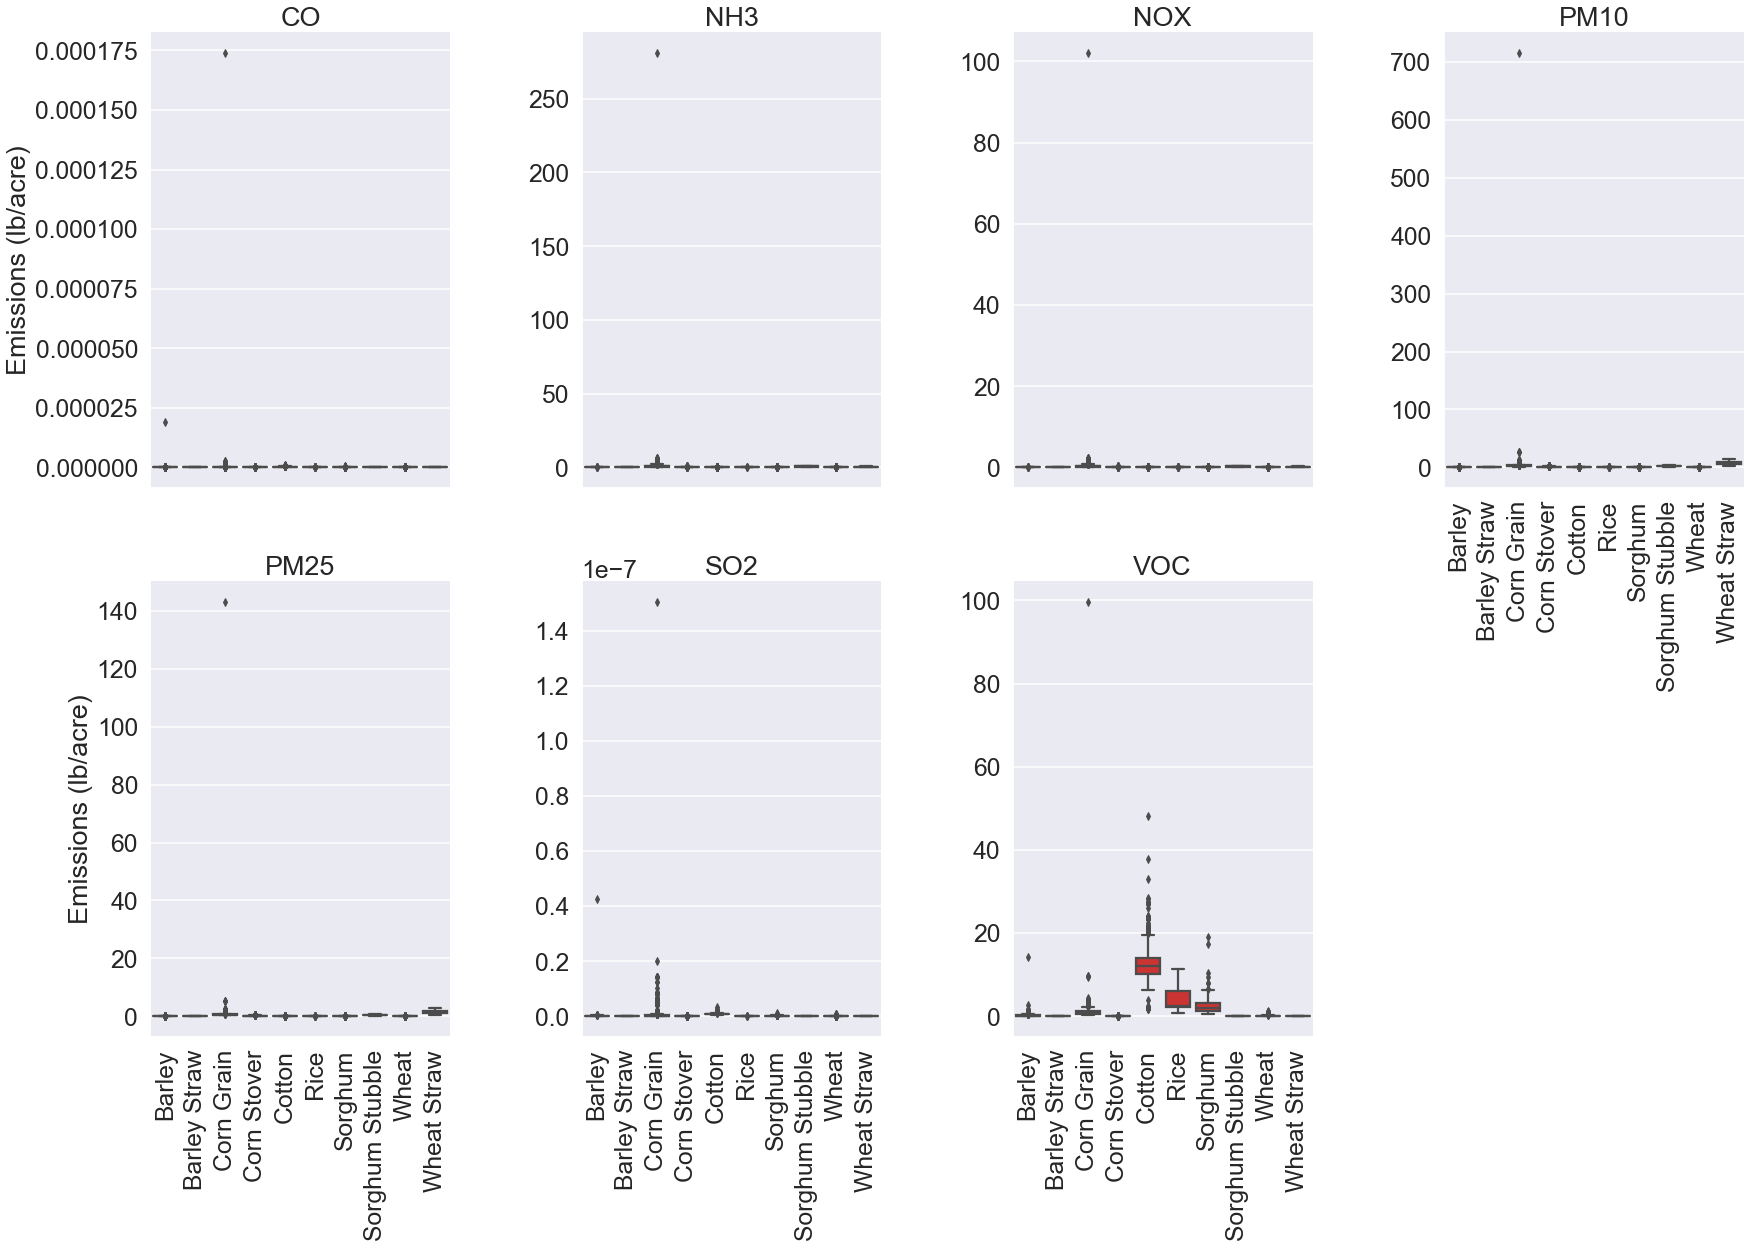

In [128]:
_order = df_subset.feedstock.unique()
_names = [_.upper() for _ in df_subset.pollutant.unique()]
sns.set_context("talk", font_scale=1.5)
# sns.set(style="whitegrid")
# sns.set(font_scale=2)
g = sns.catplot(x="feedstock",
                y="normalized_pollutant_amount",
#                 hue="pollutant",
                col="pollutant_label",
                data=df_subset,
                kind="box",
                height=8,
                aspect=.8,
                color='red',
                sharex=True,
                sharey=False,
                margin_titles=False,
                col_wrap=4,
                order=_order,
                saturation=0.6,
                dodge=False,
#                 whis=0.9
               )
(g.set_axis_labels("", "Emissions (lb/acre)")
  .set_xticklabels([_.title() for _ in _order], rotation=90)
  .set_titles("{col_name}")
#   .set(yscale = 'log')
)

In [129]:
df_subset.loc[
              ((df_subset.feedstock == 'corn grain')
                & (((df_subset.pollutant == 'co')   & (df_subset.normalized_pollutant_amount > 0.000150))
                 | ((df_subset.pollutant == 'nh3')  & (df_subset.normalized_pollutant_amount > 250))
                 | ((df_subset.pollutant == 'nox')  & (df_subset.normalized_pollutant_amount > 100))
                 | ((df_subset.pollutant == 'pm10') & (df_subset.normalized_pollutant_amount > 700))
                 | ((df_subset.pollutant == 'pm25') & (df_subset.normalized_pollutant_amount > 140))
                 | ((df_subset.pollutant == 'so2')  & (df_subset.normalized_pollutant_amount > 1.4e-7))
                 | ((df_subset.pollutant == 'voc')  & (df_subset.normalized_pollutant_amount > 90))
                )
              )
            | ((df_subset.feedstock == 'barley')
                & (((df_subset.pollutant == 'co')  & (df_subset.normalized_pollutant_amount > 0.000015))
                 | ((df_subset.pollutant == 'so2') & (df_subset.normalized_pollutant_amount > 0.2e-7))
                 | ((df_subset.pollutant == 'voc') & (df_subset.normalized_pollutant_amount > 10)))
              )
             ]

,feedstock,feedstock_measure,tillage_type,region_production,feedstock_amount,pollutant,normalized_pollutant_amount,pollutant_label
21483,barley,production,reduced tillage,51019,1.89021,co,1.898069e-05,CO
21488,barley,production,reduced tillage,51019,1.89021,so2,4.242395e-08,SO2
21489,barley,production,reduced tillage,51019,1.89021,voc,1.434235e+01,VOC
121536,corn grain,production,reduced tillage,51019,6.66793,co,1.740685e-04,CO
121537,corn grain,production,reduced tillage,51019,6.66793,nh3,2.812478e+02,NH3
121538,corn grain,production,reduced tillage,51019,6.66793,nox,1.021608e+02,NOX
121539,corn grain,production,reduced tillage,51019,6.66793,pm10,7.159451e+02,PM10
121540,corn grain,production,reduced tillage,51019,6.66793,pm25,1.431890e+02,PM25
121541,corn grain,production,reduced tillage,51019,6.66793,so2,1.505820e-07,SO2
121542,corn grain,production,reduced tillage,51019,6.66793,voc,9.972156e+01,VOC


### Notes

* how do these compare to BTS published numbers?